[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MeteoSwiss/opendata-nwp-demos/blob/main/09_constant_parameters.ipynb)
[![launch - renku](https://renkulab.io/renku-badge.svg)](https://renkulab.io/p/meteoswiss/opendata-nwp-demos/sessions/01KME52HC2FZ6ZHB30SSFG08PW/start)

# Accessing constant parameters

This notebook demonstrates the retrieval of **constant run parameters** such as grid definition, vertical layers, and surface descriptors that are not part of the forecast GRIB files, and shows how to verify grid consistency with forecast parameters. The data is provided by MeteoSwiss as part of Switzerland’s [Open Government Data (OGD) initiative](https://www.meteoswiss.admin.ch/services-and-publications/service/open-data.html).



---

## 🔍 **What You’ll Do in This Notebook**

 📥  **Retrieve vertical constants**  
    The parameter HHL is the only vertical constant; retrieval is shown for ICON-CH1-EPS and ICON-CH2-EPS.
    
| Name      | Description                                          |
|-----------|------------------------------------------------------|
| HHL       | Geometric height of the layer limits above sea level (for more information see [vertical grid](https://opendatadocs.meteoswiss.ch/e-forecast-data/e2-e3-numerical-weather-forecasting-model#vertical-grid)) |

 📥  **Retrieve horizontal constants**  
    The horizontal constant parameters retrieved in this notebook are CLON, CLAT, FR_LAND, HSURF, and SOILTYP for ICON-CH1-EPS and ICON-CH2-EPS.
    
| Name      | Description                                                                      |
|-----------|----------------------------------------------------------------------------------|
| CLON      | Longitude of the center point coordinate of each triangle on the horizontal grid |
| CLAT      | Latitude of the center point coordinate of each triangle on the horizontal grid  |
| FR_LAND   | Land cover indicator (1 for land, 0 for sea)                                     |
| HSURF     | Geometric height of the earth's surface above sea level                          |
| SOILTYPE  | Type of soil, based on the [soilType.table](https://github.com/COSMO-ORG/eccodes-cosmo-resources/blob/master/definitions/soilType.table) |

 💡  **Additional horizontal constants**  
    Other horizontal constant parameters that are not accessed in this notebook, but are accessible via the same method.

| Name      | Description                                                                      |
|-----------|----------------------------------------------------------------------------------|
| DEPTH_LK  | Lake depth                                                                       |
| FOR_D     | Deciduous forest fraction                                                        |
| FR_ICE    | Sea ice fraction                                                                 |
| FR_LAKE   | Lake fraction                                                                    |
| LAI       | Leaf area index                                                                  |
| PLCOV     | Plant cover fraction                                                             |
| ROOTDP    | Root depth                                                                       |
| SKC       | Skin conductivity                                                                |
| SSO_GAMMA | Sub-grid scale orography anisotropy                                              |
| SSO_SIGMA | Sub-grid scale orography slope                                                   |
| SSO_STDH  | Sub-grid scale orography standard deviation                                      |
| SSO_THETA | Sub-grid scale orography direction                                               |



 ✅  **Verify**  
    Using GRIB metadata (uuidOfHGrid), you'll verify grid consistency with a forecast parameter from ICON-CH2-EPS.
    
 📈  **Plot**  
    Create a profile of the vertical wind speed at Zurich airport, and show mean precipitation as a function of surface height.

---

> ⚠️ **Warning**: The constant parameters are only considered constant per run! Although they are not expected to change often, we recommend that you check that the 'uuidOfHGrid' agrees with the forecast data, especially if you cache the constants.

> ⚠️ **Warning**: At the moment, the collection assets are not versioned such that there is no way to fetch a previous version of the constant run parameters. If you are building an archive, you may need to keep track of those constants.

⚙️ Notebook Setup

This cell installs the required dependencies when running the notebook in Google Colab or RenkuLab.

It is skipped in a local Jupyter environment, where dependencies are assumed to be installed already.

In [1]:
# 📦 Notebook setup: Colab + RenkuLab
import sys, os, pathlib

IN_COLAB = "google.colab" in sys.modules
IN_RENKU = "RENKU_BASE_URL" in os.environ or "RENKU_BASE_URL_PATH" in os.environ

if IN_COLAB:
    !git clone https://github.com/MeteoSwiss/opendata-nwp-demos.git
    %cd opendata-nwp-demos

if IN_COLAB or IN_RENKU:
    !pip install poetry && poetry config virtualenvs.in-project true && poetry install --no-ansi

    venv = pathlib.Path(".venv")
    site = venv / "lib" / f"python{sys.version_info.major}.{sys.version_info.minor}" / "site-packages"
    sys.path.insert(0, str(site))
    os.environ["ECCODES_DEFINITION_PATH"] = str((venv / "share/eccodes-cosmo-resources/definitions").resolve())

## 📥 Retrieve constant parameters
The constant parameters are separated into horizontal and vertical constants, and available for both the ICON-CH1-EPS and ICON-CH2-EPS collections.

First, the urls are obtained:

In [2]:
from meteodatalab import ogd_api

# Vertical
url_ch1_vert = ogd_api.get_collection_asset_url(
    collection_id="ch.meteoschweiz.ogd-forecasting-icon-ch1",
    asset_id="vertical_constants_icon-ch1-eps.grib2"
)
url_ch2_vert = ogd_api.get_collection_asset_url(
    collection_id="ch.meteoschweiz.ogd-forecasting-icon-ch2",
    asset_id="vertical_constants_icon-ch2-eps.grib2"
)

# Horizontal
url_ch1_hor = ogd_api.get_collection_asset_url(
    collection_id="ch.meteoschweiz.ogd-forecasting-icon-ch1",
    asset_id="horizontal_constants_icon-ch1-eps.grib2"
)
url_ch2_hor = ogd_api.get_collection_asset_url(
    collection_id="ch.meteoschweiz.ogd-forecasting-icon-ch2",
    asset_id="horizontal_constants_icon-ch2-eps.grib2"
)

Next, the data can be fetched. HHL is the only vertical constant, referring to the geometric height of the layer limits above sea level. For more information, see [model grid and static data](https://opendatadocs.meteoswiss.ch/e-forecast-data/e2-e3-numerical-weather-forecasting-model#model-grid-and-static-data).

> 💡 **Tip**: The HHL parameter is also used in the notebook [05_interpolate_vertically.ipynb](05_interpolate_vertically.ipynb).

In [3]:
from meteodatalab import grib_decoder, data_source

# load CH2 vertical constants
ds_ch2_vert = grib_decoder.load(
    source=data_source.URLDataSource(urls=[url_ch2_vert]),
    request={"param": "HHL"},
    geo_coords=lambda uuid: {}
)

# load CH1 vertical constants
ds_ch1_vert = grib_decoder.load(
    source=data_source.URLDataSource(urls=[url_ch1_vert]),
    request={"param": "HHL"},
    geo_coords=lambda uuid: {}
)

ds_ch1_vert["HHL"]

<xarray.DataArray (eps: 1, ref_time: 1, lead_time: 1, z: 81, cell: 1147980)> Size: 372MB
array([[[[[22000.     , 22000.     , 22000.     , ..., 22000.     ,
           22000.     , 22000.     ],
          [19808.365  , 19808.365  , 19808.365  , ..., 19808.365  ,
           19808.365  , 19808.365  ],
          [18623.518  , 18623.518  , 18623.518  , ..., 18623.518  ,
           18623.518  , 18623.518  ],
          ...,
          [  295.3771 ,   316.1271 ,   304.6271 , ...,   769.5021 ,
             741.8771 ,   728.6271 ],
          [  263.77664,   284.77664,   273.15164, ...,   740.9016 ,
             712.7766 ,   699.4016 ],
          [  243.85379,   264.7288 ,   253.10379, ...,   720.85376,
             692.85376,   679.47876]]]]],
      shape=(1, 1, 1, 81, 1147980), dtype=float32)
Coordinates:
  * eps         (eps) int64 8B 0
  * ref_time    (ref_time) datetime64[ns] 8B 2026-07-21T09:00:00
  * lead_time   (lead_time) timedelta64[ns] 8B 00:00:00
    valid_time  (ref_time, lead_time) datetime64[ns] 8B 2026-07-21T09:00:00
  * z           (z) int64 648B 1 2 3 4 5 6 7 8 9 ... 73 74 75 76 77 78 79 80 81
Dimensions without coordinates: cell
Attributes:
    metadata:     <earthkit.data.readers.grib.metadata.StandAloneGribMetadata...
    parameter:    {'centre': 'lssw', 'paramId': 500008, 'shortName': 'HHL', '...
    geography:    {'gridType': 'unstructured_grid', 'bitmapPresent': 0}
    vref:         geo
    vcoord_type:  model_level
    origin_z:     -0.5

The following horizontal constants are accessed: CLON, CLAT, FR_LAND, HSURF and SOILTYP. For more details consult [model grid and static data](https://opendatadocs.meteoswiss.ch/e-forecast-data/e2-e3-numerical-weather-forecasting-model#model-grid-and-static-data).

| Name      | Description                                                                      |
|-----------|----------------------------------------------------------------------------------|
| CLON      | Longitude of the center point coordinate of each triangle on the horizontal grid |
| CLAT      | Latitude of the center point coordinate of each triangle on the horizontal grid  |
| FR_LAND   | Land cover indicator (1 for land, 0 for sea)                                     |
| HSURF     | Geometric height of the earth's surface above sea level                          |
| SOILTYPE  | Type of soil, based on the [soilType.table](https://github.com/COSMO-ORG/eccodes-cosmo-resources/blob/master/definitions/soilType.table)                                                                |

In [4]:
# load CH2 horizontal constants
ds_ch2_hor = grib_decoder.load(
    source=data_source.URLDataSource(urls=[url_ch2_hor]),
    request={"param": ["CLON", "CLAT", "FR_LAND", "HSURF", "SOILTYP"]},
    geo_coords=lambda uuid: {}
)

In [5]:
ds_ch2_hor.keys()

dict_keys(['FR_LAND', 'HSURF', 'SOILTYP', 'CLON', 'CLAT'])

## ✅ Verify grid consistency

The grib metadata carries a lot of information:

In [6]:
# show all metadata
ds_ch2_vert["HHL"].metadata.dump()

globalDomain,g
GRIBEditionNumber,2
tablesVersionLatestOfficial,34
tablesVersionLatest,34
grib2divider,1000000
angleSubdivisions,1000000
missingValue,9999
ieeeFloats,1
isHindcast,0
section0Length,16
identifier,GRIB


A universally unique identifier (UUID) of the horizontal grid the data is associated with is provided. You can see that the ICON-CH1-EPS and ICON-CH2-EPS models use a different grid:

In [7]:
print("CH1-EPS HHL    : ", ds_ch1_vert["HHL"].metadata.get("uuidOfHGrid"))
print("CH2-EPS HHL    : ", ds_ch2_vert["HHL"].metadata.get("uuidOfHGrid"))
print("CH2-EPS SOILTYP: ", ds_ch2_hor["SOILTYP"].metadata.get("uuidOfHGrid"))

CH1-EPS HHL    :  17643da2574959b644d254a3cd6e2bc0
CH2-EPS HHL    :  bbbd5a09855499243c7a4aa4c8762920
CH2-EPS SOILTYP:  bbbd5a09855499243c7a4aa4c8762920


We fetch now the vertical wind speed from the ICON-CH2-EPS control forecast, and compare the UUID of the grid with the UUID obtained from the vertical constants.

> ⚠️ **Warning**: The constant parameters are only considered constant per run! Although they are not expected to change often, we recommend that you check that the 'uuidOfHGrid' agrees with the forecast data, especially if you cache the constants.

In [8]:
from meteodatalab import ogd_api
from earthkit.data import config
config.set("cache-policy", "temporary")

da_W_ch2 = ogd_api.get_from_ogd(
    ogd_api.Request(
        collection="ogd-forecasting-icon-ch2",
        variable="W",
        ref_time="latest",
        perturbed=False,
        lead_time=f"P3DT10H",
    )
)

Compare the UUIDs:

In [9]:
da_HHL_ch2 = ds_ch2_vert["HHL"]
assert da_W_ch2.metadata.get("uuidOfHGrid") == da_HHL_ch2.metadata.get("uuidOfHGrid")

## 📈 Create a profile of the vertical wind speed

Now that we have verified consistency of the constant run parameters (HHL) and forecast data (W), we can create a plot.

In [10]:
from earthkit.geo import nearest_point_haversine

# target coordinates
zrh_geo_point = (47.453928, 8.565074)  # zrh airport

# get index of closest cell
p = nearest_point_haversine(zrh_geo_point, (da_W_ch2.lat.values, da_W_ch2.lon.values))[0][0]

# extract the data to plot at index p
w_profile = da_W_ch2.isel(cell=p, eps=0, ref_time=0, lead_time=0)
h_profile = da_HHL_ch2.isel(cell=p, eps=0, ref_time=0, lead_time=0)

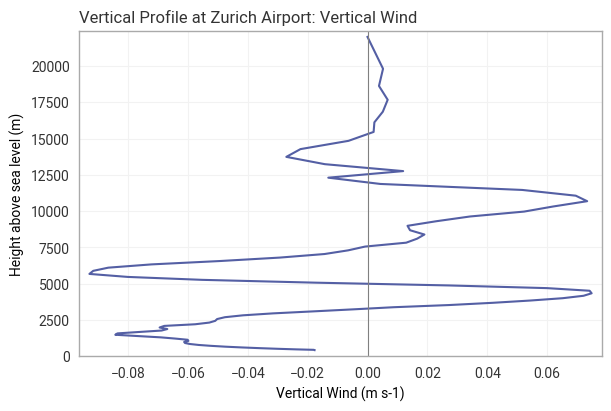

In [11]:
from earthkit.plots import Figure

# create plot

fig = Figure(rows=1, columns=1, size=(6,4))
subfig = fig.add_subplot()

subfig.line(x=w_profile, y=h_profile)
subfig.ax.axvline(x=0, color='gray', linewidth=0.8)

subfig.ax.set_xlabel(f"Vertical Wind ({da_W_ch2.metadata.get('units')})")
subfig.ax.set_ylabel(f"Height above sea level ({da_HHL_ch2.metadata.get('units')})")

subfig.ax.set_title(f"Vertical Profile at Zurich Airport: Vertical Wind", loc='left')

fig.show()

## 📈 Show the precipitation amounts against surface height

In [12]:
# fetch total precipitation for 5 days lead time
from meteodatalab import ogd_api
from earthkit.data import config
config.set("cache-policy", "temporary")

da_TOT_PREC_ch2 = ogd_api.get_from_ogd(
    ogd_api.Request(
        collection="ogd-forecasting-icon-ch2",
        variable="TOT_PREC",
        ref_time="latest",
        perturbed=False,
        lead_time=f"P5DT00H",
    )
)

In [13]:
# verify consistency of the grid
da_HSURF_ch2 = ds_ch2_hor["HSURF"]
assert da_TOT_PREC_ch2.metadata.get("uuidOfHGrid") == da_HSURF_ch2.metadata.get("uuidOfHGrid")

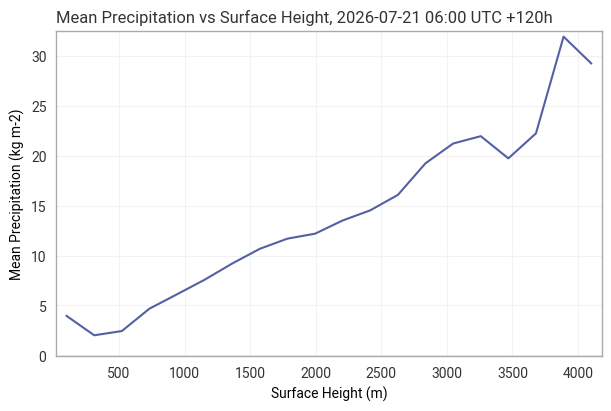

In [14]:
import numpy as np
import pandas as pd
from earthkit.plots import Figure

# squeeze to 1D arrays over cells
prec_vals = da_TOT_PREC_ch2.squeeze().values
hsurf_vals = da_HSURF_ch2.squeeze().values

# bin cells by surface height and compute mean precipitation per bin
n_bins = 20
bins = np.linspace(hsurf_vals.min(), hsurf_vals.max(), n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

df = pd.DataFrame({"prec": prec_vals, "hsurf": hsurf_vals})
df["bin"] = pd.cut(df["hsurf"], bins=bins, labels=bin_centers, include_lowest=True)
mean_prec = df.groupby("bin", observed=True)["prec"].mean()

ref_time = pd.Timestamp(da_TOT_PREC_ch2.ref_time.values[0]).strftime("%Y-%m-%d %H:%M UTC")
lead_time = pd.Timedelta(da_TOT_PREC_ch2.lead_time.values[0])
lead_hours = int(lead_time.total_seconds() / 3600)

# create plot
fig = Figure(rows=1, columns=1, size=(6,4))
subfig = fig.add_subplot()

subfig.line(x=mean_prec.index.astype(float).values, y=mean_prec.values)

subfig.ax.set_xlabel(f"Surface Height ({da_HSURF_ch2.metadata.get('units')})")
subfig.ax.set_ylabel(f"Mean Precipitation ({da_TOT_PREC_ch2.metadata.get('units')})")
subfig.ax.set_title(f"Mean Precipitation vs Surface Height, {ref_time} +{lead_hours}h", loc='left')
subfig.ax.set_ylim(bottom=-0.1)

fig.show()